# Capstone EDA — Content Refresh Opportunity Scoring

**Lane:** Refresh / Content Opportunity Scoring  
**Data:** `data/raw/content_refresh_anonymized.csv` — 30,000 rows × 44 columns, 32 pseudonymized clients  
**Goal:** Understand distributions, missingness, trends, and inter-client variation before feature engineering.

> All client names, domains, and URLs are pseudonymized. No private data is displayed.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd().parent.parent
RAW_PATH = ROOT / 'data' / 'raw' / 'content_refresh_anonymized.csv'
OUTPUT_DIR = ROOT / 'outputs'
CHART_DIR = OUTPUT_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')

df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')
print(f'Clients: {df.client_id.nunique()}')
print(f'Content items: {df.content_id.nunique()}')
df.head(3)

Shape: (30000, 44)
Clients: 32
Content items: 30000


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


## 1. Label Distribution (trend_direction)

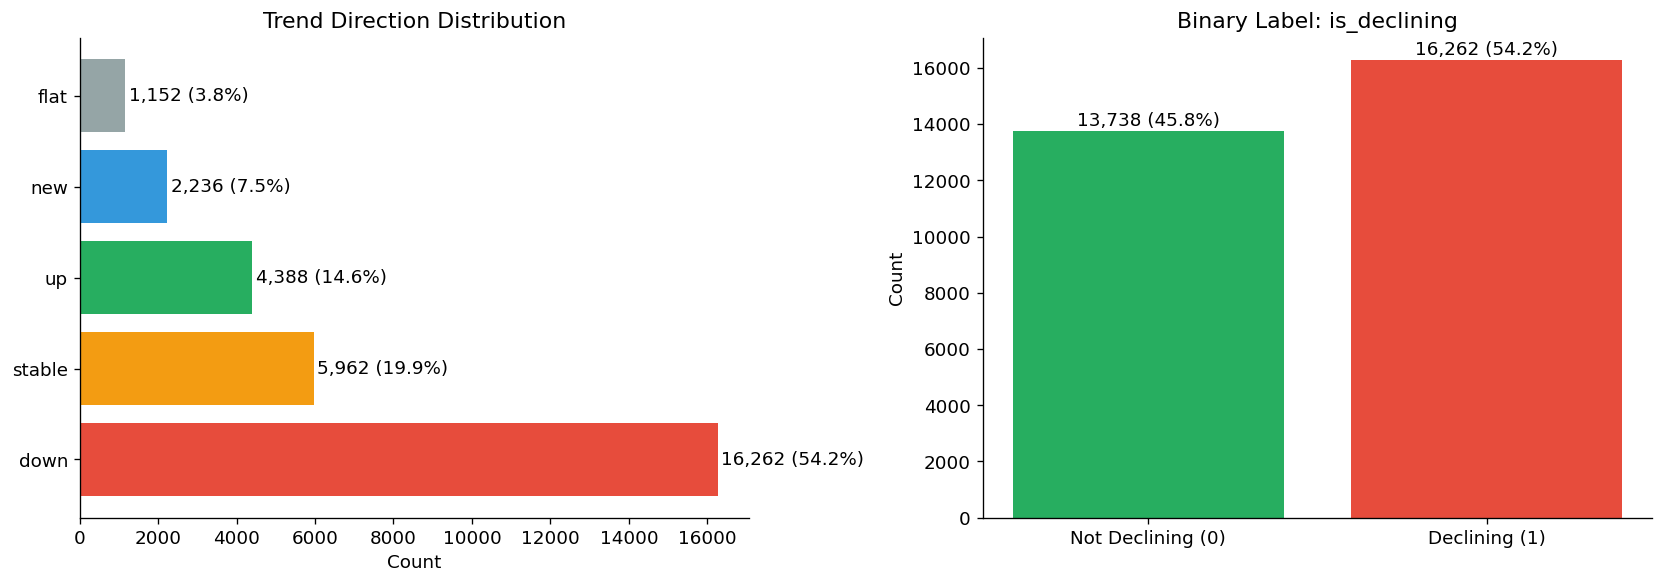


Declining rate: 0.542 (16,262/30,000)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trend_counts = df['trend_direction'].value_counts()
colors = {'down': '#E74C3C', 'stable': '#F39C12', 'up': '#27AE60', 'new': '#3498DB', 'flat': '#95A5A6'}
trend_colors = [colors.get(k, '#999') for k in trend_counts.index]

axes[0].barh(trend_counts.index, trend_counts.values, color=trend_colors)
axes[0].set_title('Trend Direction Distribution')
axes[0].set_xlabel('Count')
for i, v in enumerate(trend_counts.values):
    axes[0].text(v + 100, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center')

is_declining = (df['trend_direction'] == 'down').astype(int)
axes[1].bar(['Not Declining (0)', 'Declining (1)'], [len(is_declining) - is_declining.sum(), is_declining.sum()],
            color=['#27AE60', '#E74C3C'])
axes[1].set_title('Binary Label: is_declining')
axes[1].set_ylabel('Count')
for i, v in enumerate([len(is_declining) - is_declining.sum(), is_declining.sum()]):
    axes[1].text(i, v + 200, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_label_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nDeclining rate: {is_declining.mean():.3f} ({is_declining.sum():,}/{len(df):,})')

## 2. Missingness Analysis

Missingness is **systematic, not random** — keyword-context columns are missing along `content_type` lines.

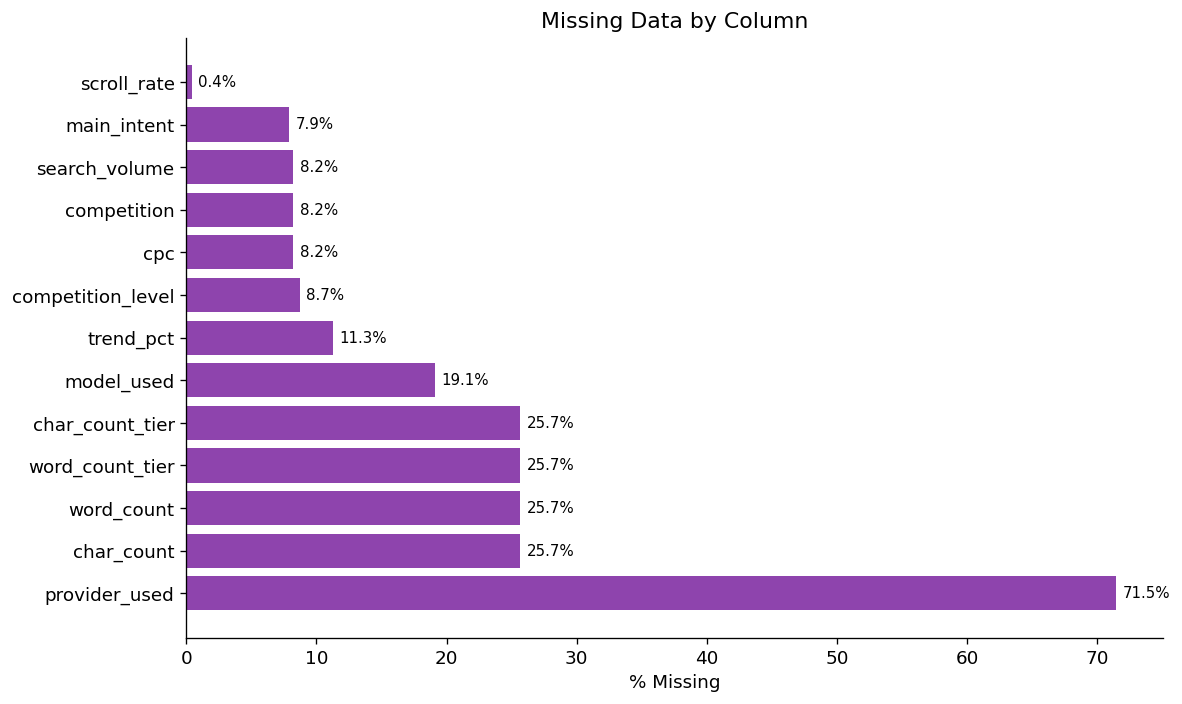


Missingness by content_type:

  keyword article (27,207 rows):
    provider_used: 71.3%
    char_count: 28.3%
    word_count: 28.3%
    word_count_tier: 28.3%
    char_count_tier: 28.3%
    model_used: 21.1%

  feedly article (2,096 rows):
    search_volume: 100.0%
    competition: 100.0%
    competition_level: 100.0%
    cpc: 100.0%
    main_intent: 100.0%
    provider_used: 70.0%
    trend_pct: 51.9%

  comparison article (697 rows):
    provider_used: 83.4%


In [3]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing.index, missing.values, color='#8E44AD')
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
for i, v in enumerate(missing.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_missingness.png', bbox_inches='tight')
plt.show()

print('\nMissingness by content_type:')
for ct in df['content_type'].dropna().unique():
    subset = df[df['content_type'] == ct]
    ct_missing = (subset.isnull().mean() * 100).sort_values(ascending=False)
    ct_missing = ct_missing[ct_missing > 20]
    if len(ct_missing) > 0:
        print(f'\n  {ct} ({len(subset):,} rows):')
        for col, pct in ct_missing.items():
            print(f'    {col}: {pct:.1f}%')

## 3. Traffic Distributions (heavy-tailed)

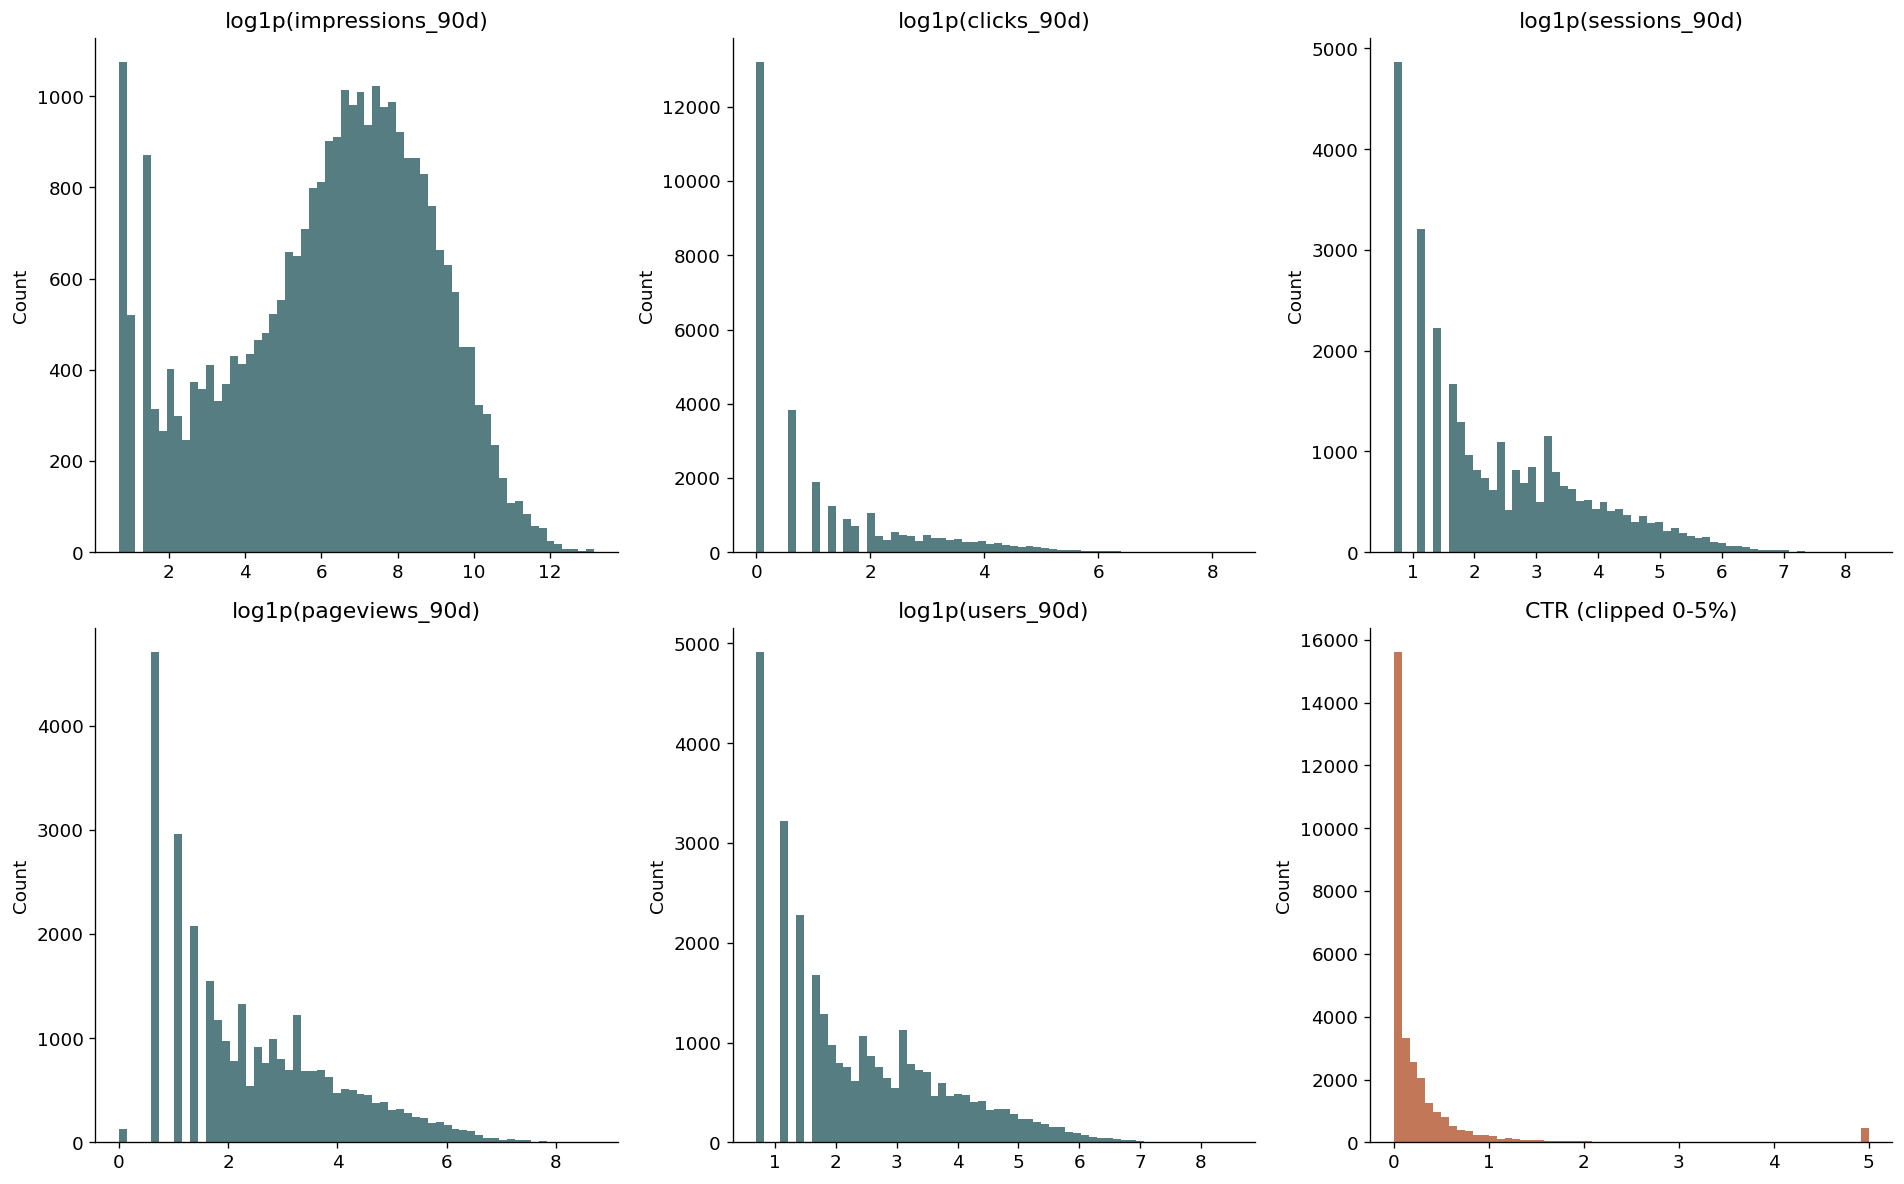

Traffic summary (raw):
       impressions_90d  clicks_90d  sessions_90d  pageviews_90d  users_90d
count          30000.0     30000.0       30000.0        30000.0    30000.0
mean            5200.4        16.1          37.1           49.9       35.9
std            16838.0        75.1         107.1          152.1      103.7
min                1.0         0.0           1.0            0.0        1.0
25%               81.0         0.0           2.0            2.0        2.0
50%              731.0         1.0           7.0            8.0        7.0
75%             3615.2         7.0          27.0           33.0       27.0
max           517715.0      4178.0        4345.0         5998.0     4913.0


In [4]:
traffic_cols = ['impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d', 'users_90d']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(traffic_cols):
    axes[i].hist(np.log1p(df[col].clip(lower=0)), bins=60, color='#2A5D63', alpha=0.8)
    axes[i].set_title(f'log1p({col})')
    axes[i].set_ylabel('Count')

axes[5].hist(df['ctr'].clip(0, 5), bins=60, color='#B4552F', alpha=0.8)
axes[5].set_title('CTR (clipped 0-5%)')
axes[5].set_ylabel('Count')

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_traffic_distributions.png', bbox_inches='tight')
plt.show()

print('Traffic summary (raw):')
print(df[traffic_cols].describe().round(1))

## 4. Per-Client Variation

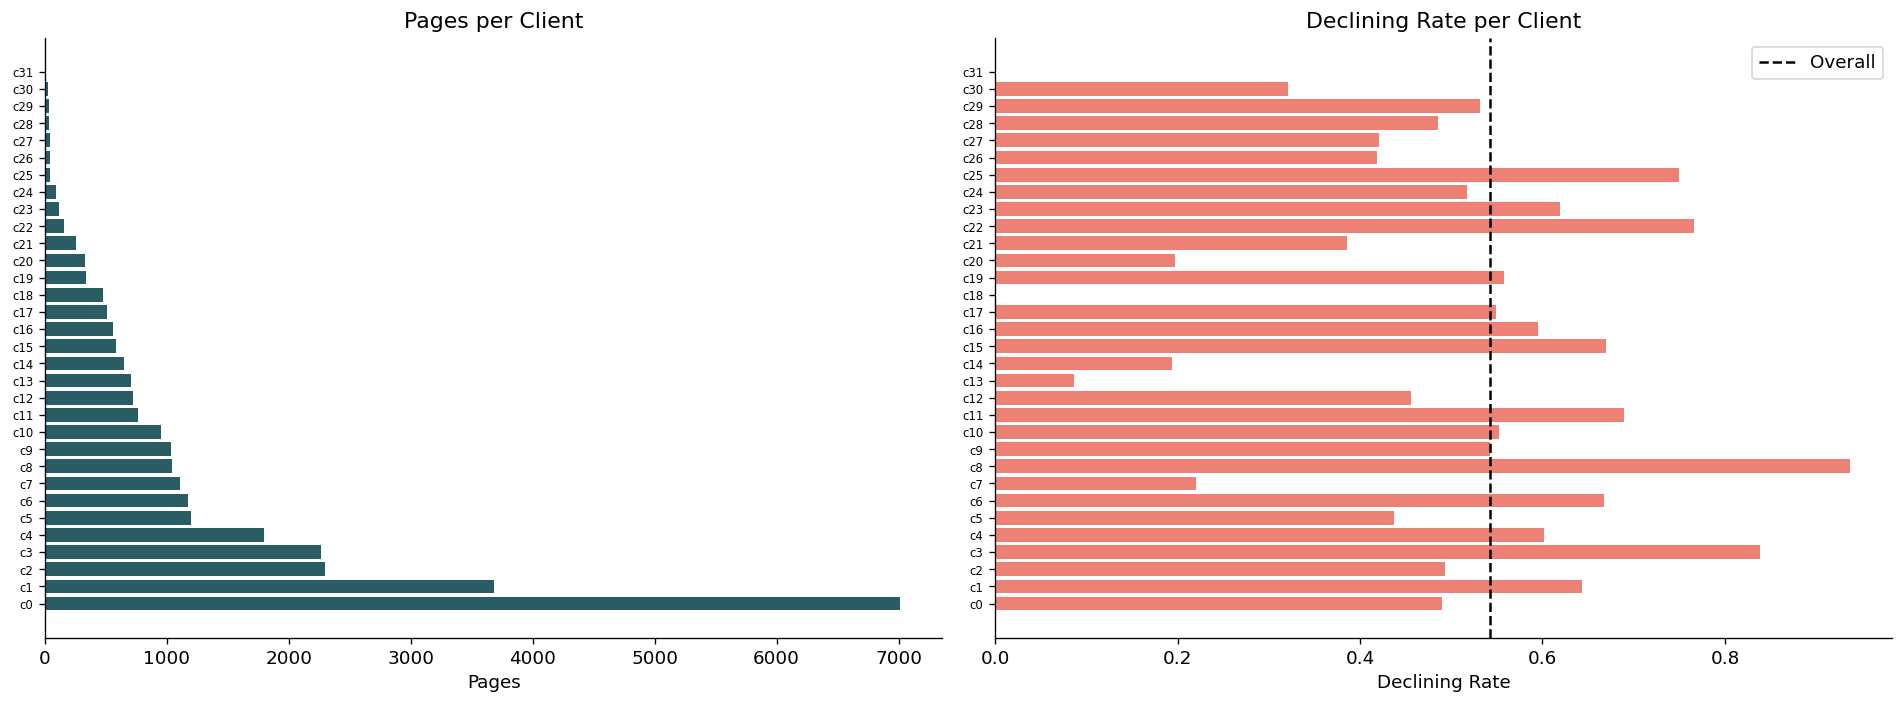


Declining rate range: 0.00 - 0.94
Pages per client: 3 - 7008 (median: 567)


In [5]:
client_stats = df.groupby('client_id').agg(
    n_pages=('content_id', 'count'),
    declining_rate=('trend_direction', lambda x: (x == 'down').mean()),
    median_impressions=('impressions_90d', 'median'),
    median_ctr=('ctr', 'median'),
    median_position=('avg_position', 'median'),
).reset_index().sort_values('n_pages', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(client_stats)), client_stats['n_pages'], color='#2A5D63')
axes[0].set_yticks(range(len(client_stats)))
axes[0].set_yticklabels([f'c{i}' for i in range(len(client_stats))], fontsize=7)
axes[0].set_xlabel('Pages')
axes[0].set_title('Pages per Client')

axes[1].barh(range(len(client_stats)), client_stats['declining_rate'], color='#E74C3C', alpha=0.7)
axes[1].set_yticks(range(len(client_stats)))
axes[1].set_yticklabels([f'c{i}' for i in range(len(client_stats))], fontsize=7)
axes[1].set_xlabel('Declining Rate')
axes[1].set_title('Declining Rate per Client')
axes[1].axvline(x=df['trend_direction'].eq('down').mean(), color='black', linestyle='--', label='Overall')
axes[1].legend()

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_per_client.png', bbox_inches='tight')
plt.show()

print(f'\nDeclining rate range: {client_stats["declining_rate"].min():.2f} - {client_stats["declining_rate"].max():.2f}')
print(f'Pages per client: {client_stats["n_pages"].min()} - {client_stats["n_pages"].max()} (median: {client_stats["n_pages"].median():.0f})')

## 5. Content Type & Intent Breakdown

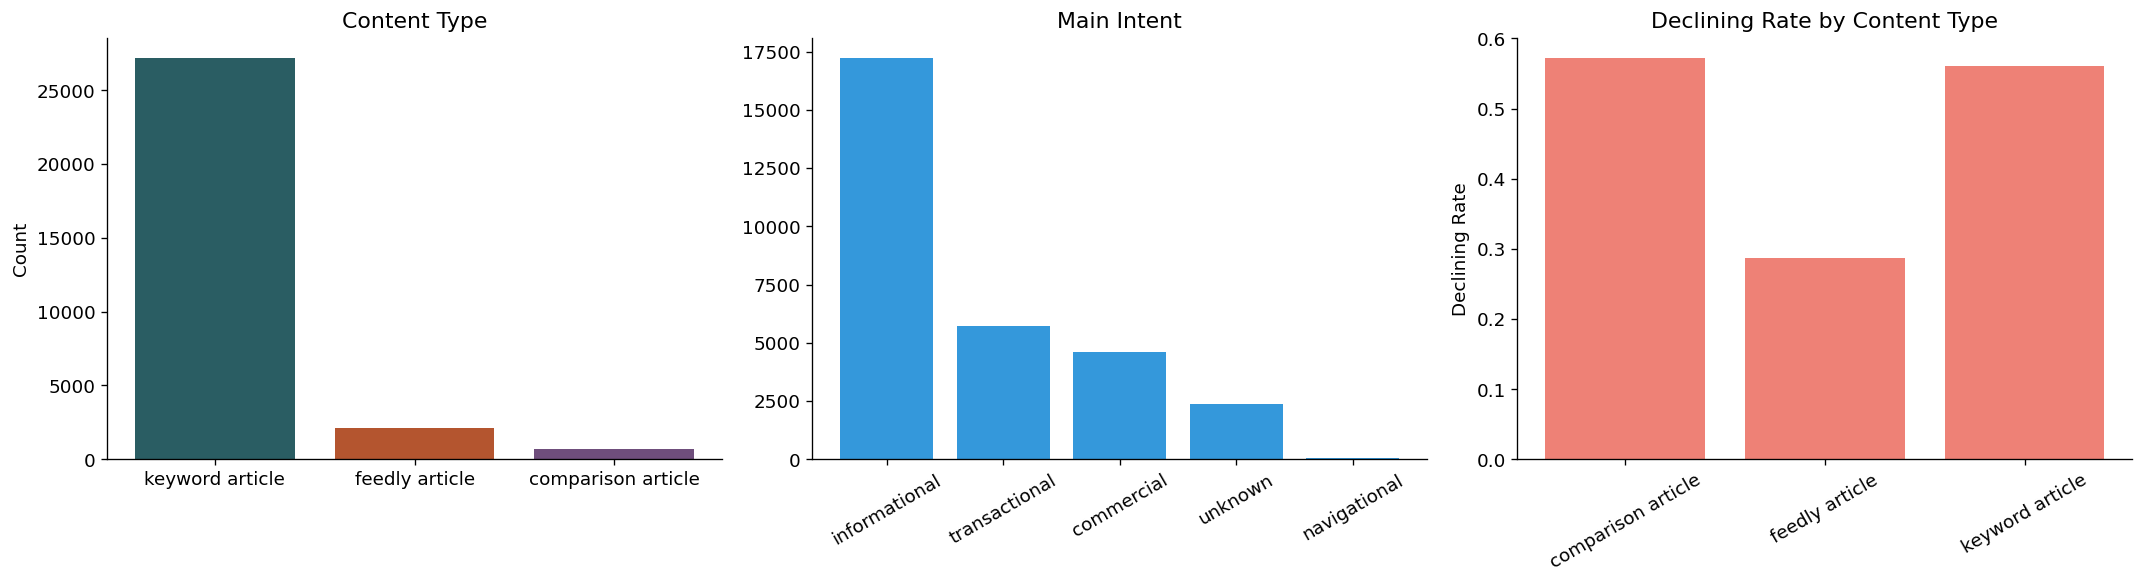

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ct_counts = df['content_type'].value_counts()
axes[0].bar(ct_counts.index, ct_counts.values, color=['#2A5D63', '#B4552F', '#6F4E7C'])
axes[0].set_title('Content Type')
axes[0].set_ylabel('Count')

intent_counts = df['main_intent'].fillna('unknown').value_counts()
axes[1].bar(intent_counts.index, intent_counts.values, color='#3498DB')
axes[1].set_title('Main Intent')
axes[1].tick_params(axis='x', rotation=30)

ct_decline = df.groupby('content_type').apply(lambda x: (x['trend_direction'] == 'down').mean())
axes[2].bar(ct_decline.index, ct_decline.values, color='#E74C3C', alpha=0.7)
axes[2].set_title('Declining Rate by Content Type')
axes[2].set_ylabel('Declining Rate')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_content_type.png', bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap (numeric features only)

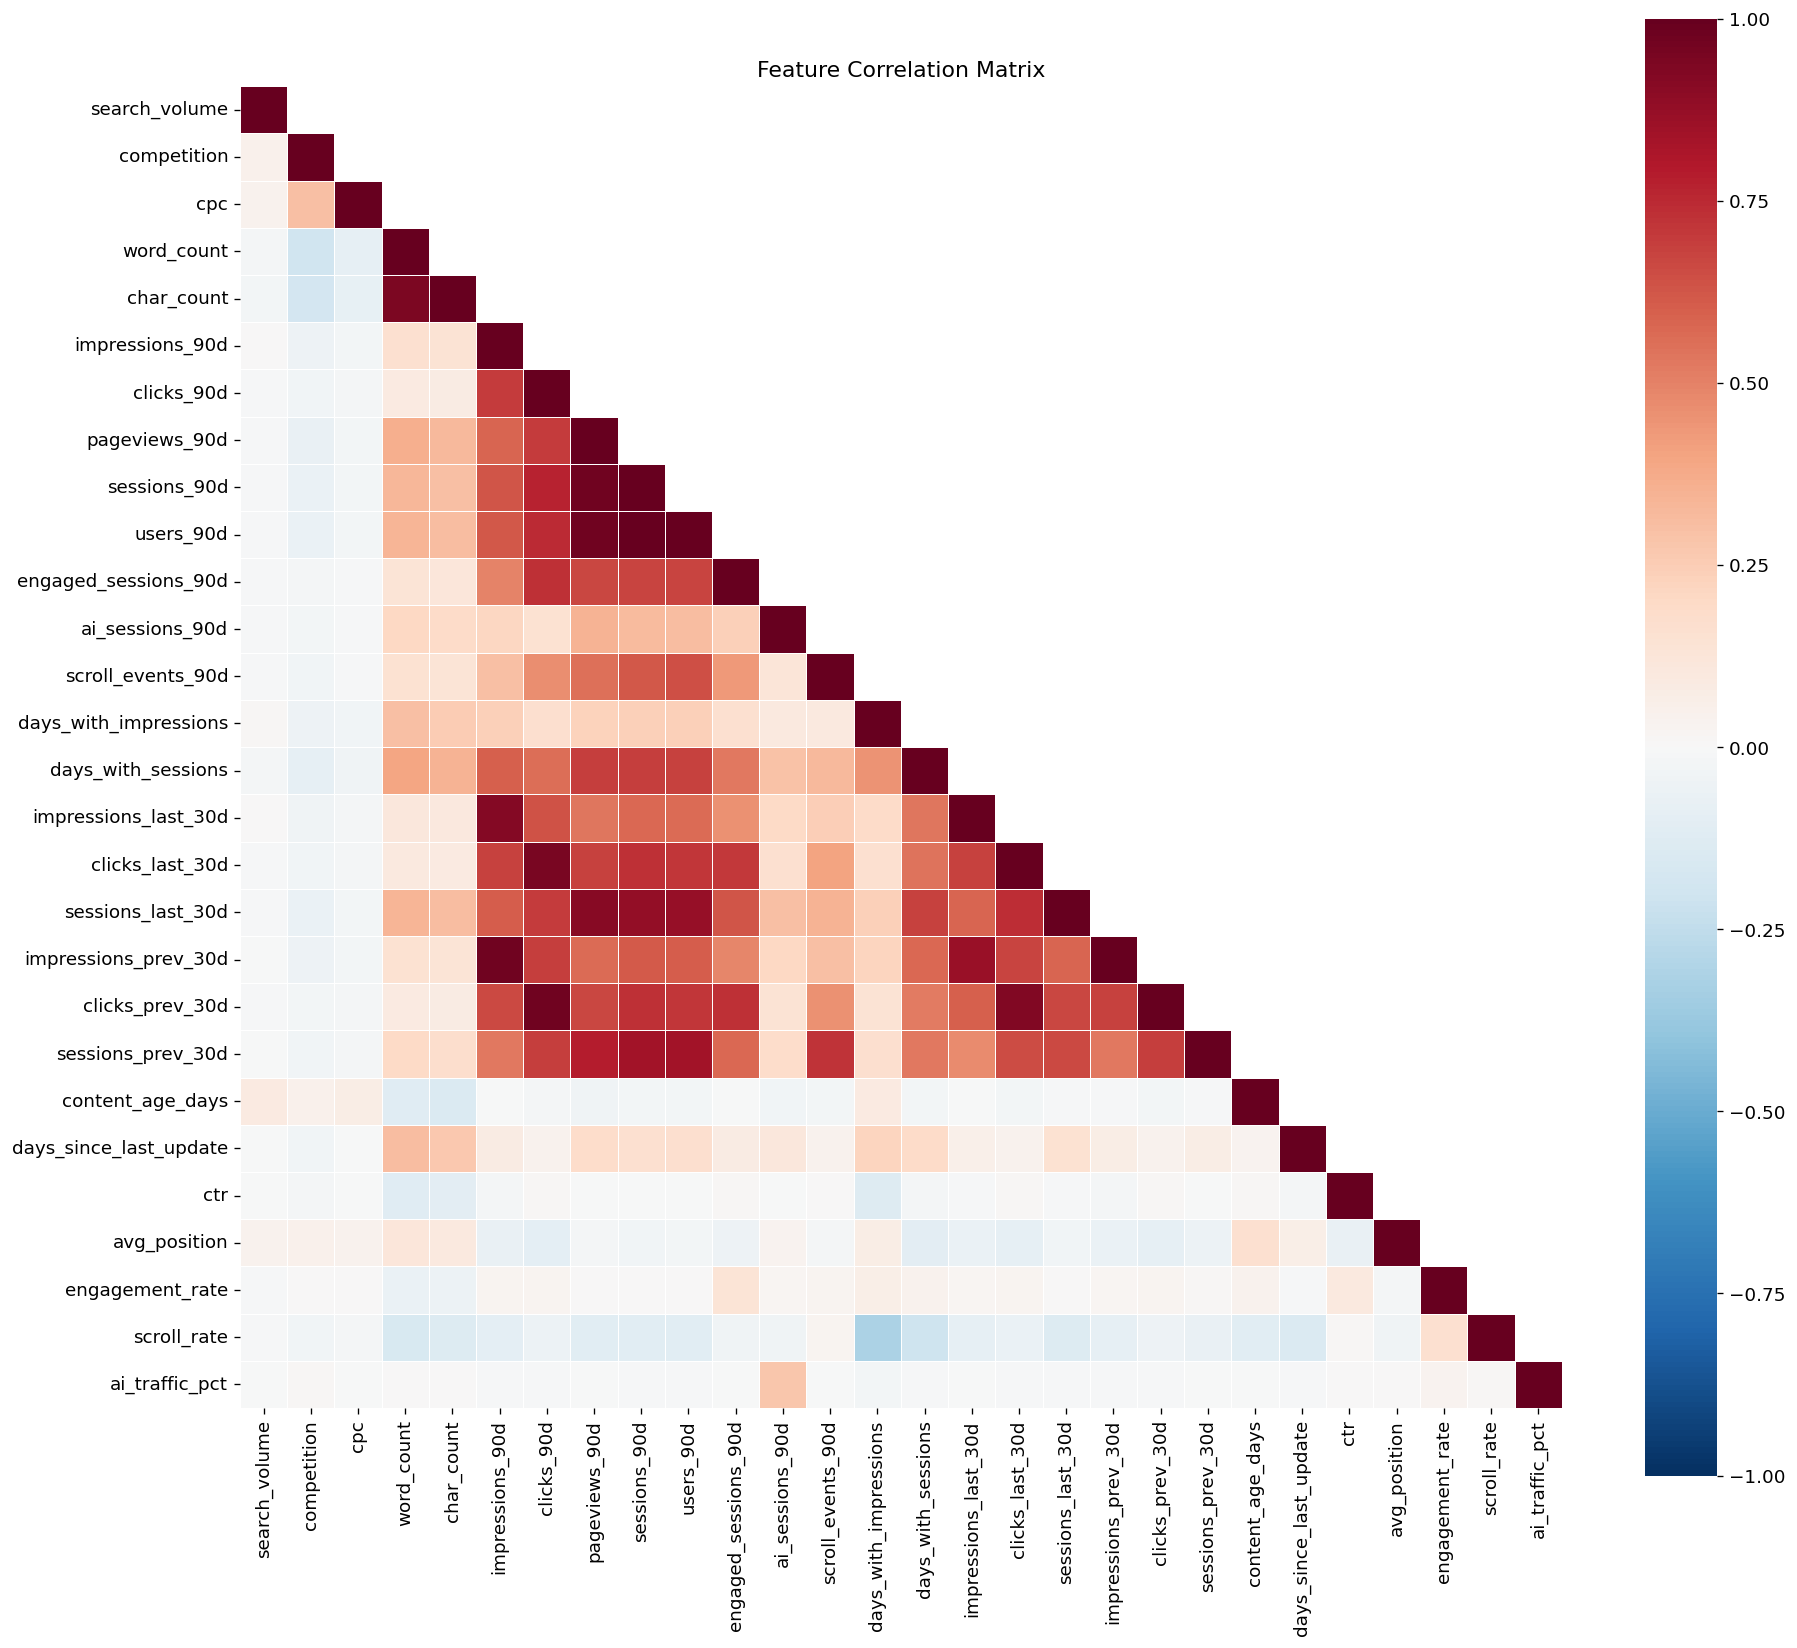

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude label-derived columns
exclude = ['trend_pct', 'age_tier_order']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.2f', annot=False)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Momentum & Trend Analysis

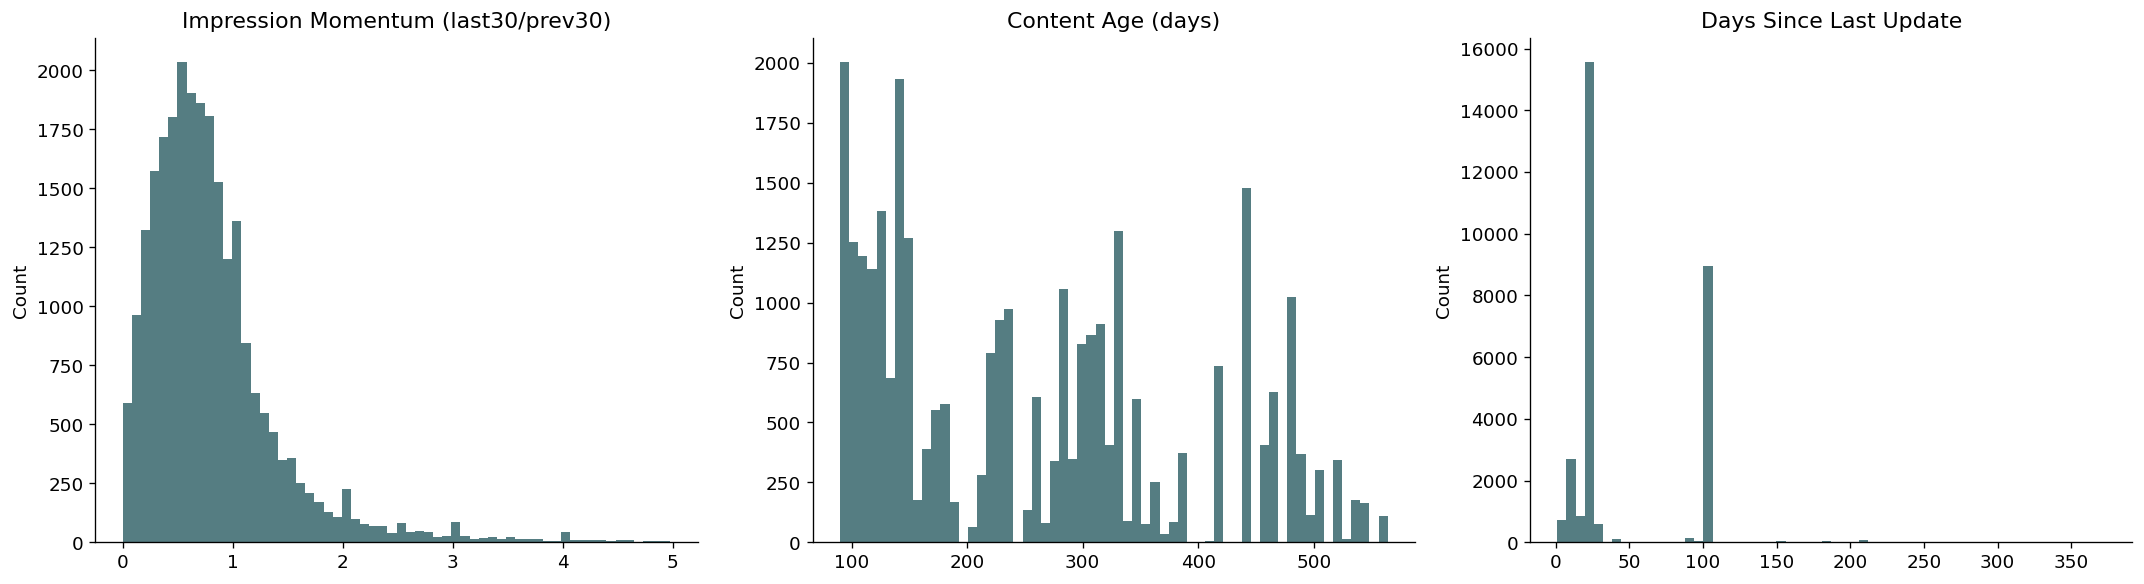


Momentum ratio stats (prev_30 > 0):
count    24953.000
mean         0.810
std          0.606
min          0.002
25%          0.418
50%          0.688
75%          1.000
max          4.978
Name: momentum_ratio, dtype: float64

Content age: min=90, max=564, median=236


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Impression momentum: last_30 vs prev_30
valid = df[(df['impressions_prev_30d'] > 0) & (df['impressions_last_30d'] > 0)].copy()
valid['momentum_ratio'] = valid['impressions_last_30d'] / valid['impressions_prev_30d']
valid = valid[valid['momentum_ratio'] < 5]  # clip outliers

for i, (col, title) in enumerate([
    ('momentum_ratio', 'Impression Momentum (last30/prev30)'),
    ('content_age_days', 'Content Age (days)'),
    ('days_since_last_update', 'Days Since Last Update'),
]):
    data = valid[col] if col == 'momentum_ratio' else df[col].dropna()
    axes[i].hist(data, bins=60, color='#2A5D63', alpha=0.8)
    axes[i].set_title(title)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_momentum.png', bbox_inches='tight')
plt.show()

print(f'\nMomentum ratio stats (prev_30 > 0):')
print(valid['momentum_ratio'].describe().round(3))
print(f'\nContent age: min={df["content_age_days"].min()}, max={df["content_age_days"].max()}, median={df["content_age_days"].median():.0f}')

## 8. Position vs CTR (sanity check)

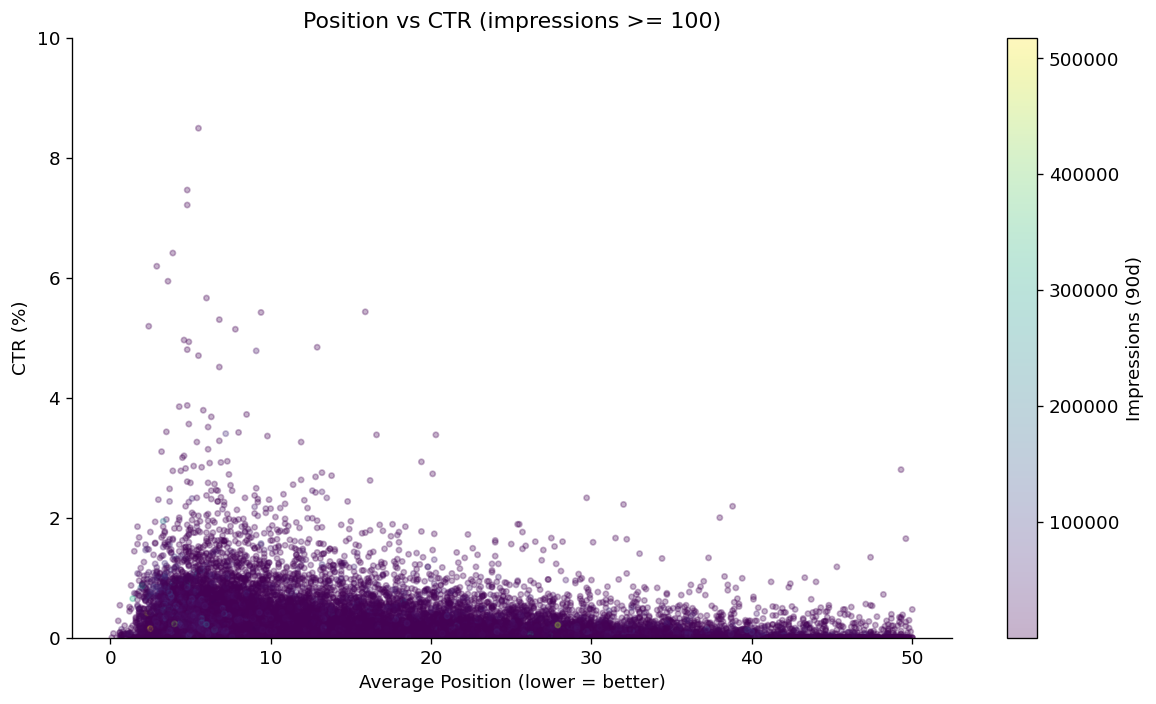


Median CTR by position bucket (impressions >= 100):
            median   mean  count
pos_bucket                      
top_3         0.19  0.337    555
page_1        0.23  0.354   8660
striking      0.15  0.256   5876
page_3_5      0.06  0.142   6037


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
valid_pos = df[(df['avg_position'] > 0) & (df['avg_position'] <= 50) & (df['impressions_90d'] >= 100)]

scatter = ax.scatter(valid_pos['avg_position'], valid_pos['ctr'],
                     c=valid_pos['impressions_90d'], cmap='viridis', alpha=0.3, s=10)
ax.set_xlabel('Average Position (lower = better)')
ax.set_ylabel('CTR (%)')
ax.set_title('Position vs CTR (impressions >= 100)')
plt.colorbar(scatter, label='Impressions (90d)')
ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_position_vs_ctr.png', bbox_inches='tight')
plt.show()

# Position bucket medians
pos_bins = [0, 3, 10, 20, 50]
pos_labels = ['top_3', 'page_1', 'striking', 'page_3_5']
valid_pos['pos_bucket'] = pd.cut(valid_pos['avg_position'], bins=pos_bins, labels=pos_labels, right=True)
print('\nMedian CTR by position bucket (impressions >= 100):')
print(valid_pos.groupby('pos_bucket')['ctr'].agg(['median', 'mean', 'count']).round(3))

## 9. EDA Summary → Save Key Stats

In [10]:
eda_stats = {
    'n_rows': int(len(df)),
    'n_cols': int(df.shape[1]),
    'n_clients': int(df['client_id'].nunique()),
    'n_content_items': int(df['content_id'].nunique()),
    'declining_rate': float((df['trend_direction'] == 'down').mean()),
    'trend_direction_counts': {k: int(v) for k, v in df['trend_direction'].value_counts().items()},
    'content_type_counts': {k: int(v) for k, v in df['content_type'].value_counts().items()},
    'client_declining_rate_range': {
        'min': float(client_stats['declining_rate'].min()),
        'max': float(client_stats['declining_rate'].max()),
    },
    'median_impressions_90d': float(df['impressions_90d'].median()),
    'median_ctr': float(df['ctr'].median()),
    'median_position': float(df['avg_position'][df['avg_position'] > 0].median()),
    'median_content_age_days': float(df['content_age_days'].median()),
    'top_missing_cols': {k: float(v) for k, v in missing.head(8).items()},
}

stats_path = OUTPUT_DIR / 'eda_stats.json'
stats_path.write_text(json.dumps(eda_stats, indent=2))
print(f'Saved EDA stats to {stats_path}')
print(json.dumps(eda_stats, indent=2))

Saved EDA stats to /Users/keremozcan/Desktop/flyrank_intern/flyrank-ml-internship-starter/outputs/eda_stats.json
{
  "n_rows": 30000,
  "n_cols": 44,
  "n_clients": 32,
  "n_content_items": 30000,
  "declining_rate": 0.5420666666666667,
  "trend_direction_counts": {
    "down": 16262,
    "stable": 5962,
    "up": 4388,
    "new": 2236,
    "flat": 1152
  },
  "content_type_counts": {
    "keyword article": 27207,
    "feedly article": 2096,
    "comparison article": 697
  },
  "client_declining_rate_range": {
    "min": 0.0,
    "max": 0.9367209971236817
  },
  "median_impressions_90d": 731.0,
  "median_ctr": 0.07,
  "median_position": 11.4,
  "median_content_age_days": 236.0,
  "top_missing_cols": {
    "provider_used": 71.46000000000001,
    "char_count": 25.663333333333334,
    "word_count": 25.663333333333334,
    "word_count_tier": 25.663333333333334,
    "char_count_tier": 25.663333333333334,
    "model_used": 19.11,
    "trend_pct": 11.293333333333333,
    "competition_level": 